<a href="https://colab.research.google.com/github/fionastern28/comp-neuro/blob/main/SDH_modeling_summer2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##SDH Modeling



This Colab notebook is an initial attempt at having a workspace.  I have downloaded the initial Medlock et al 2022 code locally on my computer.  I intend to have one github repository.  The repo will contain both this notebook as well as possibly any changes I make to the Medlock code.

My instinct is to do most initial exploratory work in the notebook, but perhaps to move over to a VS Code file structure when working with a more complete model

Below is an attempt to understand the spike time generation

In [ ]:
!pip install neuron netpyne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.3/435.3 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
print("Upload three things: cells.py, genrn.py, and mods.zip")
files.upload()
files.upload()
files.upload()

Upload three things: cells.py, genrn.py, and mods.zip


Saving mods.zip to mods.zip


Saving cells.py to cells.py


Saving genrn.py to genrn.py


{'genrn.py': b'\'\'\'\ngeneric neuron modelling class\n\ncalling from python calls genrn with t-junction electrophysiology and morphology--\nperipheral fiber, drg with soma, central fiber\nproperties taken from Waxman\n\'\'\'\nfrom neuron import h\nimport logging as lgg\nimport re\n\nclass gesec():\n\n    def __init__(self, name=\'sec\', ions={\'na\': 58, \'k\': -92, \'ca\': -129, \'cl\': -89}):\n        self.name  = name\n        self.sec   = h.Section(name=name)\n        self.mechs = []\n        self.pps   = []\n        self.ions  = {}\n        for ion in ions:\n            self.ions[ion] = {\'e\': ions[ion], \'mechs\': []}\n        self.insert = self.im = self.insert_mech\n        self.ims = self.insert_mechs\n        self.gm = self.get_mechs\n        self.gs = self.get_sec\n\n    def insert_mechs(self, mechs, *mmechs):\n        if isinstance(mechs, str):\n            self.insert_mech(mechs)\n            for mech in mmechs:\n                self.insert_mech(mech)\n        else:\n   

In [ ]:
!unzip -o mods.zip
!ls           # expect: cells.py  genrn.py  mods/  mods.zip
!ls mods      # expect: a bunch of .mod files (HH2.mod, iCaL.mod, ...)

Archive:  mods.zip
   creating: mods/
  inflating: __MACOSX/._mods         
  inflating: mods/HH2.mod            
  inflating: __MACOSX/mods/._HH2.mod  
  inflating: mods/NMDA_DynSyn.mod    
  inflating: __MACOSX/mods/._NMDA_DynSyn.mod  
  inflating: mods/vecevent.mod       
  inflating: __MACOSX/mods/._vecevent.mod  
  inflating: mods/borgka.mod         
  inflating: __MACOSX/mods/._borgka.mod  
  inflating: mods/iNaP.mod           
  inflating: __MACOSX/mods/._iNaP.mod  
  inflating: mods/vsource.mod        
  inflating: __MACOSX/mods/._vsource.mod  
  inflating: mods/AMPA_DynSyn.mod    
  inflating: __MACOSX/mods/._AMPA_DynSyn.mod  
  inflating: mods/iCaL.mod           
  inflating: __MACOSX/mods/._iCaL.mod  
  inflating: mods/KDR.mod            
  inflating: __MACOSX/mods/._KDR.mod  
  inflating: mods/GABAa_DynSyn.mod   
  inflating: __MACOSX/mods/._GABAa_DynSyn.mod  
  inflating: mods/KDRI.mod           
  inflating: __MACOSX/mods/._KDRI.mod  
  inflating: mods/Glycine_DynSyn.mod 

In [ ]:
!nrnivmodl mods

/content
cfiles =
Mod files: "mods/AMPA_DynSyn.mod" "mods/B_A.mod" "mods/B_DR.mod" "mods/B_NA.mod" "mods/borgka.mod" "mods/CaIntraCellDyn.mod" "mods/GABAa_DynSyn.mod" "mods/GABAb_DynSyn.mod" "mods/Glycine_DynSyn.mod" "mods/HH2.mod" "mods/HH2new.mod" "mods/iCaAN.mod" "mods/iCaL.mod" "mods/iKCa.mod" "mods/iNaP.mod" "mods/KDRI.mod" "mods/KDR.mod" "mods/NK1_DynSyn.mod" "mods/NMDA_DynSyn.mod" "mods/SS.mod" "mods/vecevent.mod" "mods/vsource.mod"

Creating 'x86_64' directory for .o files.

MODOBJS= ./AMPA_DynSyn.o ./B_A.o ./B_DR.o ./B_NA.o ./borgka.o ./CaIntraCellDyn.o ./GABAa_DynSyn.o ./GABAb_DynSyn.o ./Glycine_DynSyn.o ./HH2.o ./HH2new.o ./iCaAN.o ./iCaL.o ./iKCa.o ./iNaP.o ./KDRI.o ./KDR.o ./NK1_DynSyn.o ./NMDA_DynSyn.o ./SS.o ./vecevent.o ./vsource.o
 -> Compiling mod_func.cpp
 -> NMODL ../mods/AMPA_DynSyn.mod
 -> NMODL ../mods/B_DR.mod
 -> NMODL ../mods/B_A.mod
Translating AMPA_DynSyn.mod into /content/x86_64/AMPA_DynSyn.cpp
Thread Safe
Translating B_DR.mod into /content/x86_64/B_DR.cpp


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#returns rate of type 1 Aβ touch afferent firing over 1000 ms
def rate_SAI():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_SAI = (-1.45433609113392e-10 * key ** 3 + 1.340603396708e-6 * key ** 2 - 0.00378224210238498 * key + 4.52737468545426) * 8
            rate.append(freq_SAI)

    return rate, t

#returns rate of type 2 Aβ touch afferent firing over 1000 ms
def rate_SAII():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_SAII = (-1.45433609113392e-10 * key ** 3 + 1.340603396708e-6 * key ** 2 - 0.00378224210238498 * key + 4.52737468545426) * 8
            rate.append(freq_SAII)

    return rate, t

#returns rate of Ad firing, plugged in 0.25 for cfg.stim_ratios
def rate_Ad():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_Ad = ( -7.265297e-15 * key ** 4 + 1.573831e-10 * key ** 3 - 8.201529e-7 * key ** 2 - 0.002539930 * key + 27.18412 ) * 0.25
            rate.append(freq_Ad)

    return rate, t

#returns rate of C firing, plugged in 0.25 for cfg.stim_ratios
def rate_C():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate  = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_C = (  9.630390e-15 * key ** 4 - 2.844577e-10 * key ** 3 + 3.012887e-6 * key ** 2 - 0.01400381 * key + 31.86546 ) * 0.25
            rate.append(freq_C)

    return rate, t

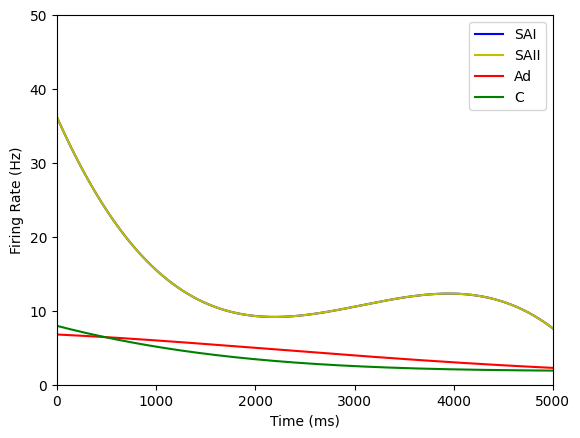

In [ ]:
ratesSAI, timeSAI = rate_SAI()
ratesSAII, timeSAII = rate_SAII()
ratesAd, timeAd = rate_Ad()
ratesC, timeC = rate_C()

# plots the rates of each type of fiber
plt.plot(timeSAI, ratesSAI, label = "SAI", color = 'b')
plt.plot(timeSAII, ratesSAII, label = "SAII", color = 'y')
plt.plot(timeAd, ratesAd, label = "Ad", color = 'r')
plt.plot(timeC, ratesC, label = "C", color = 'g')
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")

#limits to first 5 seconds (which is all that is relevant to model)
plt.axis([0, 5000, 0,50])
plt.legend()

#can see that both follow the same trajectory

Below is code taken from cells.py, it is a dictionarry, giving the conditions for a pNK1 cell with the three part model.  references mod files... might need those


In [ ]:
PROcellRule = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'dend': {'geom': {'L': 350.0, 'nseg': 5, 'diam': 2.5, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'can': {'e': 0.0, 'i': 1.0, 'o': 1.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05,
                                                'cai_tau': 2.0,
                                                'depth': 0.1},
                             'HH2': {'gnabar': 0.0, 'gkbar': 0.036, 'vtraub': -55.0}, # HH1 = 0, Kdr = 36 (fiona).   Hodgkin-Huxley 2?? (hh2)
                             'iCaAN': {'gbar': 9.099999999999999e-05}, # caAN = 0.1 x10^-12 (fiona)
                             'iCaL': {'pcabar': 3e-05}, # CaL = 3.0 x 10^-2 (fiona)
                             'iKCa': {'gbar': 0.001, 'gk': 0.0}, # k_ca = 1, NaP = 0 (fiona)
                             'pas': {'g': 4.2e-05, 'e': -65.0}}, # Leak = 4.2x 10^-2 (fiona)
                   'topol': {'parentSec': 'soma', 'parentX': 0.0, 'childX': 0.0}},
          'hillock': {'geom': {'L': 9.0, 'nseg': 3, 'diam': 1.5, 'Ra': 150.0, 'cm': 1.0},
                      'ions': {'k': {'e': -77.0, 'i': 54.4, 'o': 2.5},
                               'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                      'mechs': {'B_A': {},
                                'HH2': {'gkbar': 0.076,
                                        'gnabar': 3.45,
                                        'vtraub': -55.0},
                                'pas': {'g': 4.2e-05, 'e': -65.0}},
                      'topol': {'parentSec': 'soma', 'parentX': 1.0, 'childX': 0.0}},
          'soma': {'geom': {'L': 20.0, 'nseg': 3, 'diam': 20.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'can': {'e': 0.0, 'i': 1.0, 'o': 1.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05,
                                                'cai_tau': 1.0,
                                                'depth': 0.1},
                             'HH2': {'gkbar': 0.001075,
                                     'gnabar': 0.0,
                                     'vtraub': -55.0},
                             'iCaAN': {'gbar': 0.0},
                             'iCaL': {'pcabar': 0.0001},
                             'iKCa': {'gbar': 0.0001, 'gk': 0.0},
                             'iNaP': {'gamma': 0.5,
                                      'gnabar': 0.0001,
                                      'vsh': -5.0,
                                      'vsm': -2.0,
                                      'vtraub': -55.0},
                             'pas': {'g': 4.2e-05, 'e': -65.0}},
                   'topol': {}}}
}

In [ ]:
!pip install netpyne
from netpyne import specs, sim
import cells

In [ ]:
# code grabbed from various parts of netParams_mechanical.py


netParams = specs.NetParams() # line from clause
cells.PROcellRule['conds'] = {'cellType': 'PRO'}
cells.PROcellRule['secs']['soma']['threshold'] = 0
netParams.cellParams['NK1Rule'] = cells.PROcellRule
netParams.popParams['NK1'] = {'cellType': 'PRO', 'numCells': 1} # NK1+ neurons (projection)

# first version here: constant input
# following from claude

# IClamp holds 'amp' steady from time 'del' until 'del'+'dur'.
netParams.stimSourceParams['input'] = {
    'type': 'IClamp',
    'del': 100,     # ms: rest first, so you can see baseline
    'dur': 900,     # ms: then hold the current on for the rest of the run
    'amp': 0.1}     # nA: the constant input level  <-- the knob to change


netParams.stimTargetParams['input->NK1'] = {
    'source': 'input', 'conds': {'pop': 'NK1'},
    'sec': 'dend', 'loc': 0.5}






In [ ]:
 # ---- run settings ---- all claude here need to return
cfg = specs.SimConfig()
cfg.hParams    = {'celsius': 36, 'v_init': -60}
cfg.duration   = 1000      # ms
cfg.dt         = 0.025
cfg.recordStep = 0.1
cfg.saveFolder = 'data'     # where output goes
cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
cfg.recordTraces['V_dend'] = {'sec': 'dend', 'loc': .5, 'var': 'v'}
cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}
cfg.recordTraces['V_hillock'] = {'sec': 'hillock', 'loc': .5, 'var': 'v'}

# note measures loc. 0.5 on each, but unclear what actual model does should check

cfg.analysis['plotTraces'] = {
    'include': [0],
    'timeRange': [90, 143],     # zoom the x-axis to 100-140 ms
    'overlay': True,           # all traces on a single graph
    'saveFig': True, 'showFig': True}

sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)


Start time:  2026-06-12 12:56:36.095178




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|

  Number of cells on node 0: 1 
  Done; cell creation time = 0.01 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 3 traces of 3 types on node 0

Running simulation using NEURON for 1000.0 ms...


  Done; run time = 0.52 s; real-time ratio: 1.93.

Gathering data...
  Done; gather time = 0.00 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 95 (95.00 Hz)
  Simulated time: 1.0 s; 1 workers
  Run time: 0.52 s
Saving output as data/model_output_data.json ... 
Finished saving!
  Done; saving time = 0.07 s.
Plotting recorded cell traces ... cell
  Done; plotting time = 0.23 s

Total time = 0.84 s
